In [ ]:
# mount the data from google drive
from google.colab import drive
from google.colab import files

drive.mount("/content/drive")

# navigate to the project folder
%cd drive/MyDrive/projects/CVPR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[Errno 2] No such file or directory: 'drive/MyDrive/projects/CVPR'
/content/drive/MyDrive/projects/CVPR


In [ ]:
# list of unique scenes
import os
import numpy as np
from collections import Counter
import cv2
import math
from bs4 import BeautifulSoup
import re as re
import pandas as pd
import matplotlib.pyplot as plt

def get_coordinates(obj):
    coordinates = []

    # loop through each polygon and find every pair of x,y coordinates
    for xy in obj.groups()[1].split(';'):
        coordinates_xy = ([float(num) for num in xy.split(',')])
        coordinates.append(coordinates_xy)

    # have the polygon end at the first point
    coordinates.append(coordinates[0])
    return coordinates

def get_filled_mask(img_size, coordinates, fill_value):

    # make array of the coordinates
    polygon = np.array([coordinates], dtype=np.int32 )

    # make array of zeros the size of the image
    im = np.zeros((img_size[0],img_size[1]),dtype=np.int32)

    # fill only the area of the polygon with 1s
    return cv2.fillPoly(im,polygon, fill_value)

def list_files(path):
    """Lists all files in the specified directory."""

    files = []
    for entry in os.listdir(path):
        if os.path.isfile(os.path.join(path, entry)):
            files.append(entry[:-4])
    return files

def find_occluded(obj):
    return int(re.findall(r'occluded=\"(\d)\"', str(obj))[0])

def find_label(obj):
    return re.findall(r"label=\"(.*)\"\soccluded", str(obj))[0]

def sort_by_depth(image_name, depth_map):
    background = ['floor', 'sky', 'wall', 'grass', 'carpet', 'ground', 'ceiling',  'trees', 'water',  'road',  'pavement']
    # resize depth map
    depth_map = cv2.resize(depth_map[0,0], (1024, 768), interpolation = cv2.INTER_AREA)
    depth_map = 1- depth_map
    # pull up annotations
    obj_iterator = parse_xml(image_name, xml_dir = 'annotations/')

    # create empty lists
    occluded_dfs = []
    unoccluded_dfs = []
    unoccluded_labels = []
    occluded_labels = []

    for obj in obj_iterator:
      obj_label = find_label(obj)
      if obj_label not in background:

        # fill mask
        coordinates = get_coordinates(obj)
        mask = get_filled_mask((768, 1024), coordinates, 1)

        # sort by occulusion label
        occlusion_bool = find_occluded(obj)

        if occlusion_bool == 1:
            occluded_dfs.append(pd.DataFrame({'obj':[obj], 'mean': [np.mean(np.nonzero(depth_map*mask))]}))
            occluded_labels.append(obj_label)

        if occlusion_bool == 0:
            unoccluded_dfs.append(pd.DataFrame({'obj':[obj], 'mean': [np.mean(np.nonzero(depth_map*mask))]}))
            unoccluded_labels.append(obj_label)

    # highest values are those closest, sort from most to least depth
    occluded_df = pd.concat(occluded_dfs)
    occluded_df['label'] = occluded_labels
    occluded_df = occluded_df.sort_values(by='mean', ascending=False)

    unoccluded_df = pd.concat(unoccluded_dfs)
    unoccluded_df['label'] = unoccluded_labels
    unoccluded_df = unoccluded_df.sort_values(by='mean', ascending=False)

    depth_df = pd.concat([occluded_df, unoccluded_df])

    # return list of object annotation coordinates, and list of object labels sorted by depth
    return depth_df['obj'].tolist(), depth_df['label'].to_list()

def make_mask_arrays(image_name_list, depth_arrays):

  # set empty lists
  labels = []
  images = []
  num_ids = []

  x = 0

  for i, image in enumerate(image_name_list):

    # make empty array same size as image
    mask_array = np.zeros((768, 1024),dtype=np.uint8)
    sorted_annotations, object_labels = sort_by_depth(image, depth_arrays[i])

    for b, obj in enumerate(sorted_annotations):
      unique_id = b + 1
      mask = get_filled_mask((768, 1024), get_coordinates(obj), unique_id)
      mask_array = np.where(mask_array * mask > 0, 0, mask_array) + mask

    # find mask ids that are missing and add them back in at the top
    for c in range(len(sorted_annotations)):
      unique_id = c + 1
      if np.any(np.isin(mask_array, unique_id)) == False:
        obj = sorted_annotations[c]
        print(image, unique_id, object_labels[c])
        mask = get_filled_mask((768, 1024), get_coordinates(obj), unique_id)
        mask_array = np.where(mask_array * mask > 0, 0, mask_array) + mask

    labels.extend(object_labels)
    num_ids.extend([i + x for i in range(1, len(sorted_annotations)+1)])
    images.extend([image] * len(object_labels))

    mask_array[mask_array != 0] += x
    x = x + len(sorted_annotations)
    # save sorted image masks
    np.save(str('/content/drive/MyDrive/projects/CVPR/masks2/' + image + '.npy'), mask_array)

 # the guide is the list of objects and their unique numerical ids
  guide = pd.DataFrame()
  guide['image'] = images
  guide['label'] = labels
  guide['id'] = num_ids
  guide.to_csv('label_ids1.csv')

def parse_xml(image_name, xml_dir):
    xml_filename = image_name + '.xml'
    with open(os.path.join(xml_dir, xml_filename)) as infile:
        contents = infile.read()
        soup = BeautifulSoup(contents,'xml')
        xml = soup.prettify()

        # hardcoded regex to find each object annotation
        obj_regex = re.compile(r'label=\"(?P<object>\w*)".*points=\"(?P<coordinates>[\d\.,;]*)\"')

        # find all objects within XML file
        obj_iterator = obj_regex.finditer(xml)
    return obj_iterator

def load_numpy_arrays(file_paths):
    """
    Takes a list of file paths to numpy arrays and returns a list of the loaded arrays.

    Parameters:
    file_paths (list of str): A list of file paths to numpy arrays.

    Returns:
    list of numpy.ndarray: A list containing the loaded numpy arrays.
    """

    loaded_arrays = [np.load(file) for file in file_paths]
    return loaded_arrays


In [ ]:
image_dir = 'images/'
image_name_list = list_files(image_dir)
image_name_list.sort()
depth_dir = 'depth/'
depth_paths = [depth_dir + item + '_disp.npy' for item in image_name_list]
depth_arrays = load_numpy_arrays(depth_paths)
make_mask_arrays(image_name_list, depth_arrays)

target_acquarium 4 coral
target_alley 1 roadblock
target_amusementpark 2 tree
target_atticstorage 20 suitcases
target_bakery 7 pastries
target_beach 15 people
target_boating_IDS01 5 lifesaver
target_buffet 14 food
target_building_IDS01 2 plant
target_building_IDS01 3 bus_stop
target_building_IDS01 6 plant
target_city 1 building
target_classroom 3 supplies
target_classroom 7 supplies
target_clothingstore 5 clothes
target_clothingstore 6 clothes
target_coffeeshop 5 drinkware
target_coffeeshop 6 drinkware
target_coffeeshop 7 drinkware
target_constructionsite 1 building
target_constructionsite 3 machine
target_deli 1 food
target_diner 18 utensil
target_diningroom_IDS01 4 balcony
target_diningroom_IDS01 5 building
target_dock 2 boat
target_dock 3 dock
target_dock 4 boat
target_dock 6 boat
target_driveway 1 window
target_driveway 8 plant
target_field 1 tree
target_field 9 building
target_field 10 building
target_fishingvillage 1 building
target_fishingvillage 2 building
target_fishingvillage

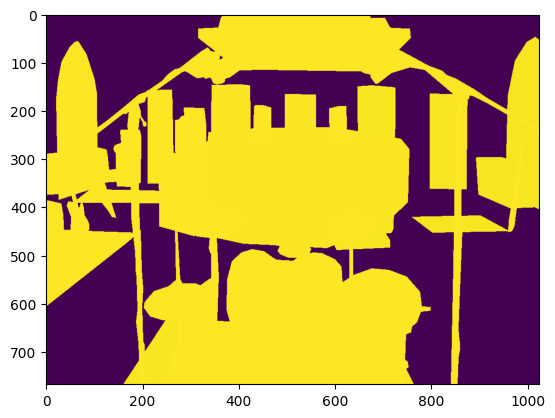

In [ ]:
# median of masked area
test_image = 'target_recordingstudio'

test_array = np.load('masks2/' + test_image + '.npy')

plt.imshow(test_array,  vmin=1001, vmax=np.mean(test_array[np.nonzero(test_array)]))

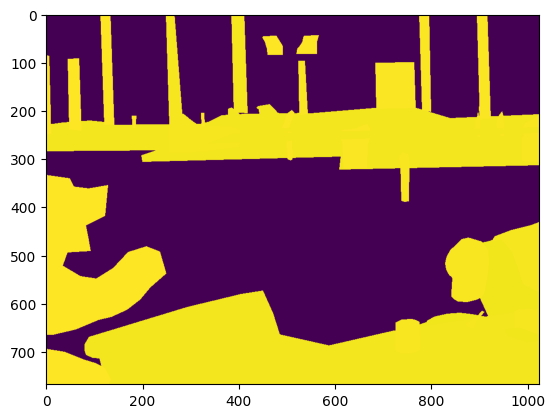

In [ ]:
# median of masked area
test_image = 'target_pool_IDS01'

test_array = np.load('masks2/' + test_image + '.npy')

plt.imshow(test_array)

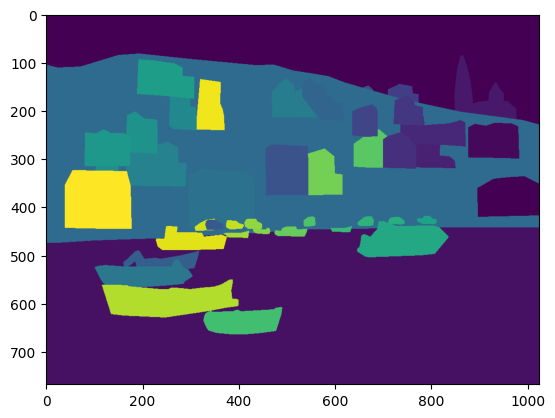

In [ ]:

plt.imshow(test_array, vmin=np.min(test_array[np.nonzero(test_array)]))

In [ ]:
np.unique(test_array)

array([   0,  995,  996,  997,  998,  999, 1000, 1001, 1002, 1003, 1004,
       1005, 1006, 1007, 1008], dtype=int32)

In [ ]:
guide = pd.read_csv('label_ids1.csv')
guide[guide['image']=='target_office_IDS01']

,Unnamed: 0,image,label,id
1650,1650,target_office_IDS01,computer,1651
1651,1651,target_office_IDS01,drawer,1652
1652,1652,target_office_IDS01,desk,1653
1653,1653,target_office_IDS01,corkboard,1654
1654,1654,target_office_IDS01,computer,1655
1655,1655,target_office_IDS01,bag,1656
1656,1656,target_office_IDS01,paper,1657
1657,1657,target_office_IDS01,chairs,1658
1658,1658,target_office_IDS01,drawer,1659
1659,1659,target_office_IDS01,bag,1660


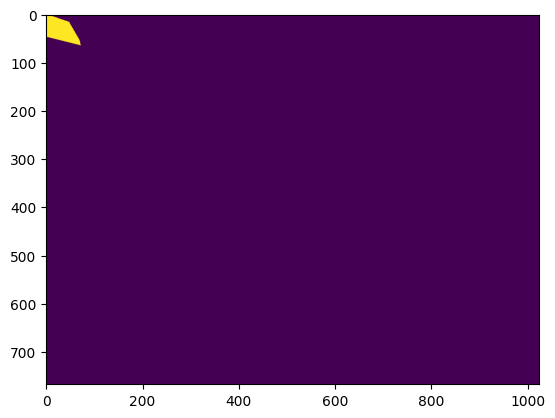

In [ ]:
test_image = 'target_kitchen_IDS01'

test_array = np.load('masks2/' + test_image + '.npy')

plt.imshow(test_array==	1441)

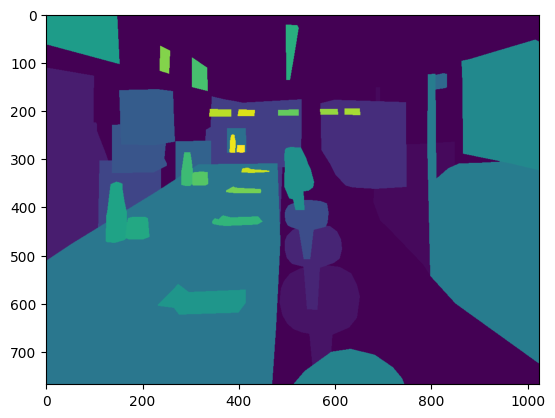

In [ ]:
# old way diner
plt.imshow(mask_array)

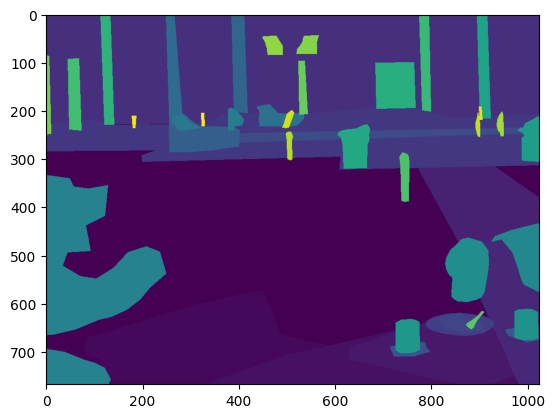

In [ ]:
plt.imshow(mask_array)

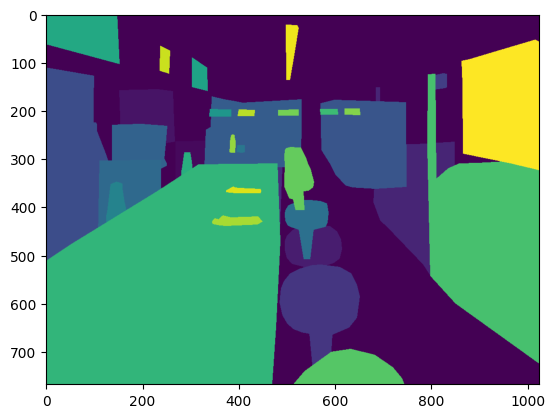

In [ ]:
# median of mask array diner
plt.imshow(mask_array)